# Task 1 — Exploratory Data Analysis

This notebook performs EDA for the insurance portfolio covering:
- data summarization and dtype review
- data quality (missing values)
- univariate, bivariate, and multivariate analysis
- geographic trends and outlier detection
- answers to the guiding questions requested by the project brief.


In [3]:

import sys

sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_data

from preprocessing import (
    calculate_loss_ratio,
    calculate_margin,
    missing_value_summary
)

from eda_utils import (
    plot_histogram,
    plot_boxplot,
    plot_correlation
)


In [5]:

df = load_data(
    "../data/MachineLearningRating_v3.csv"
)

df.head()



c:\Users\edenteklehaimanot\insurance-risk-analytics\notebooks\../src\data_loader.py:6: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep="|")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


**Data Summarization & Dtypes**


In [6]:
df.info()

df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[us]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               1000098 non-null  str           
 5   LegalType                 1000098 non-null  str           
 6   Title                     1000098 non-null  str           
 7   Language                  1000098 non-null  str           
 8   Bank                      854137 non-null   str           
 9   AccountType               959866 non-null   str           
 10  MaritalStatus             991839 non-null   str           
 11  Gender                    990562 non-null   str           
 1

,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1000098,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,2015-02-28 10:49:29.147424,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
min,1.000000e+00,1.400000e+01,2013-10-01 00:00:00,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,2015-01-01 00:00:00,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2015-04-01 00:00:00,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,2015-06-01 00:00:00,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,2015-08-01 00:00:00,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05
std,6.329371e+04,5.290039e+03,NaN,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03


**Data Quality Assessment (Missing Values)**


In [7]:

missing_value_summary(df)


NumberOfVehiclesInFleet     1000098
CrossBorder                  999400
CustomValueEstimate          779642
Rebuilt                      641901
Converted                    641901
WrittenOff                   641901
NewVehicle                   153295
Bank                         145961
AccountType                   40232
Gender                         9536
MaritalStatus                  8259
VehicleType                     552
make                            552
mmcode                          552
Model                           552
Cylinders                       552
bodytype                        552
kilowatts                       552
NumberOfDoors                   552
VehicleIntroDate                552
cubiccapacity                   552
CapitalOutstanding                2
SubCrestaZone                     0
ItemType                          0
Province                          0
Country                           0
PostalCode                        0
MainCrestaZone              

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df = calculate_loss_ratio(df)

df = calculate_margin(df)

In [10]:
df["LossRatio"].mean()

np.float64(0.3498846581363079)

In [11]:
province_loss = (
    df.groupby("Province")["LossRatio"]
    .mean()
    .sort_values()
)

province_loss

Province
Free State       0.106209
Northern Cape    0.203831
Eastern Cape     0.235589
KwaZulu-Natal    0.264746
North West       0.285348
Western Cape     0.341750
Limpopo          0.348712
Mpumalanga       0.392698
Gauteng          0.428889
Name: LossRatio, dtype: float64

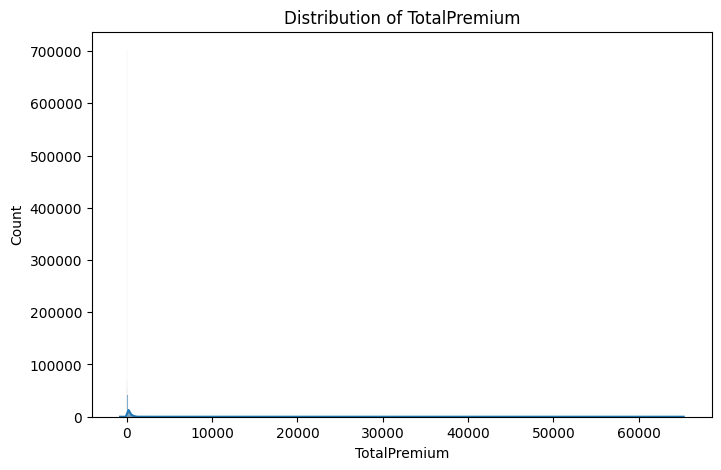

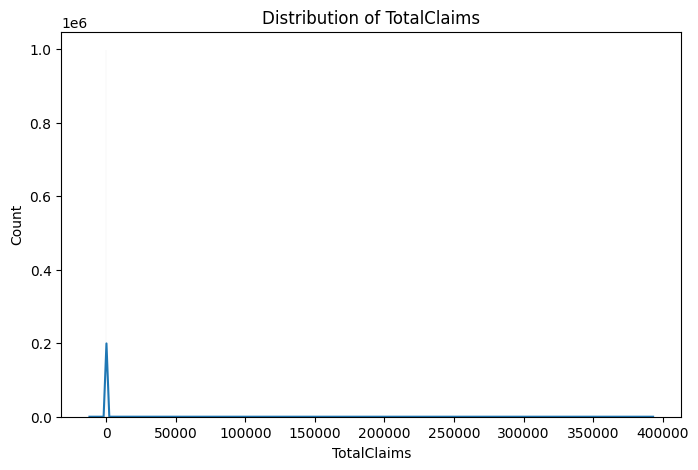

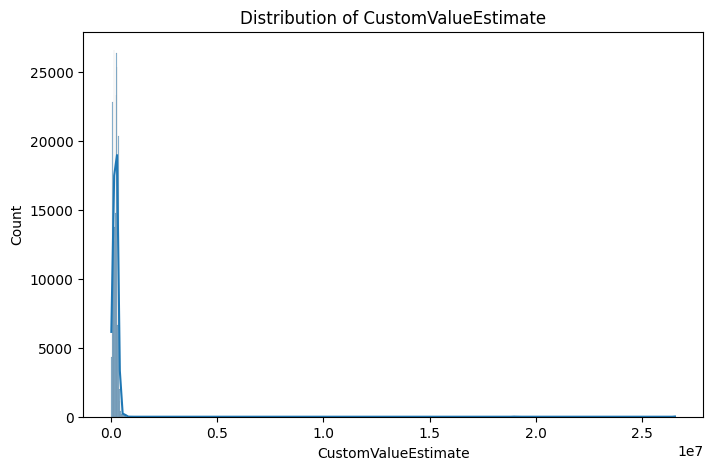

In [12]:
plot_histogram(df, "TotalPremium")

plot_histogram(df, "TotalClaims")

plot_histogram(
    df,
    "CustomValueEstimate"
)

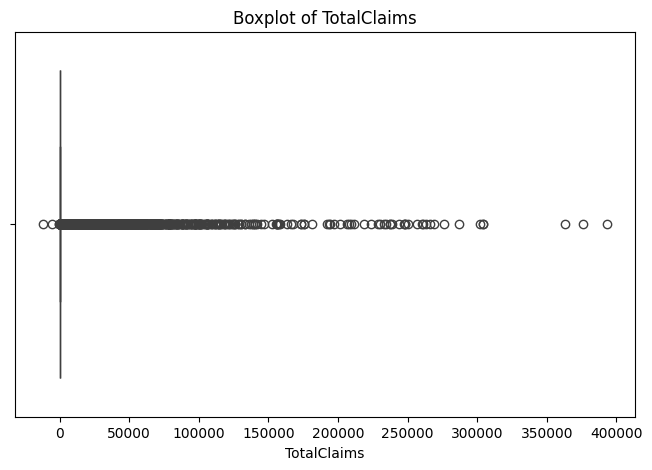

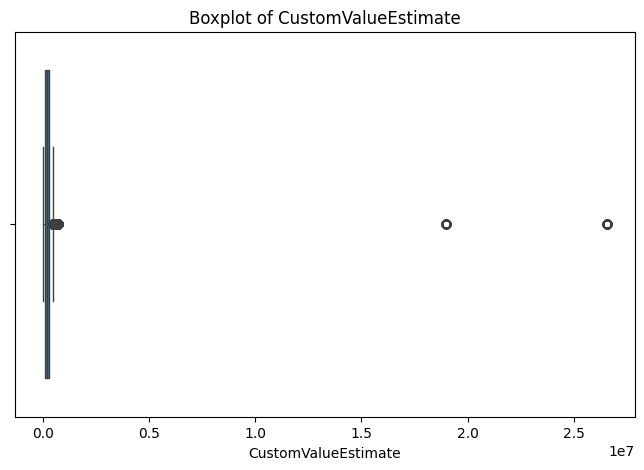

In [13]:
plot_boxplot(df, "TotalClaims")

plot_boxplot(
    df,
    "CustomValueEstimate"
)

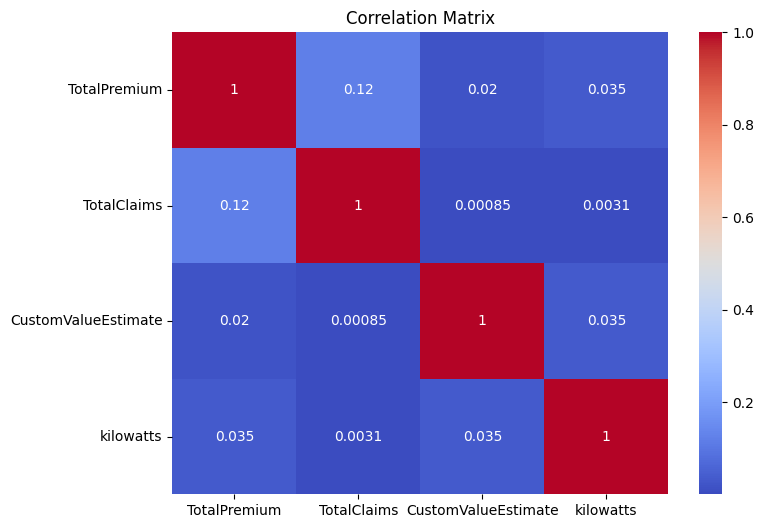

In [14]:
plot_correlation(
    df,
    [
        "TotalPremium",
        "TotalClaims",
        "CustomValueEstimate",
        "kilowatts"
    ]
)

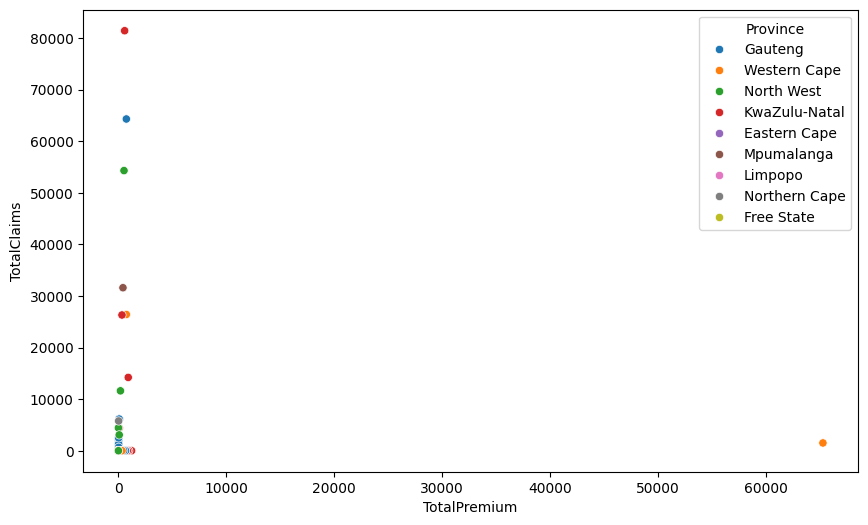

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(5000),
    x="TotalPremium",
    y="TotalClaims",
    hue="Province"
)

plt.show()

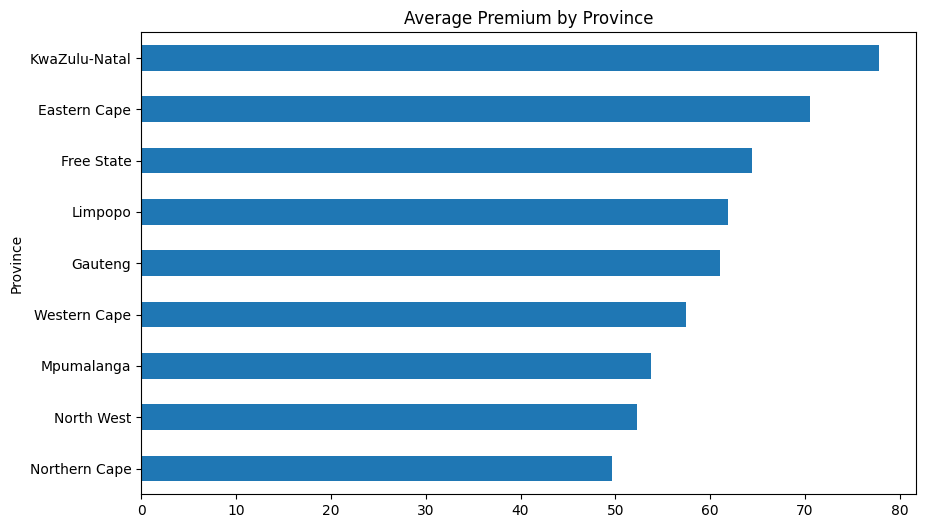

In [16]:
province_premium = (
    df.groupby("Province")
    ["TotalPremium"]
    .mean()
    .sort_values()
)

province_premium.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title(
    "Average Premium by Province"
)

plt.show()

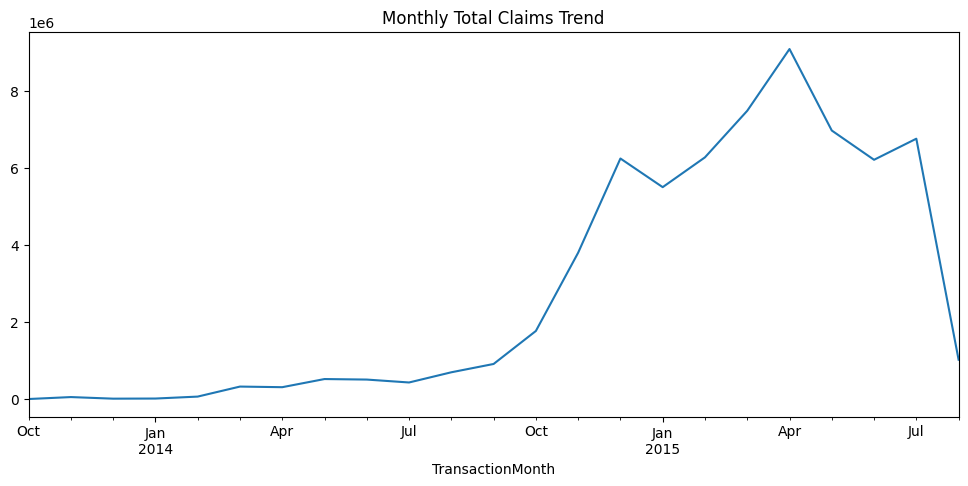

In [17]:
monthly_claims = (
    df.groupby(
        df["TransactionMonth"]
        .dt.to_period("M")
    )["TotalClaims"]
    .sum()
)

monthly_claims.plot(
    figsize=(12, 5)
)

plt.title(
    "Monthly Total Claims Trend"
)

plt.show()

In [18]:
top_claims = (
    df.groupby("make")
    ["TotalClaims"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_claims

make
SUZUKI                                 419.634546
JMC                                    191.684795
HYUNDAI                                174.215195
MARCOPOLO                              156.794806
AUDI                                   137.843083
POLARSUN                               134.044800
B.A.W                                  132.934016
FIAT                                   108.625642
BMW                                     90.558050
IVECO                                   89.667017
Name: TotalClaims, dtype: float64

In [19]:
import sys

sys.path.append("../src")

import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_data

from modeling import (
    prepare_model_data,
    train_claim_classifier,
    train_claim_regressor
)

In [20]:
X, y_clf, y_reg, features = (
    prepare_model_data(df)
)

In [21]:
(
    clf_model,
    X_test,
    y_test,
    predictions,
    accuracy
) = train_claim_classifier(
    X,
    y_clf
)

print("Accuracy:", accuracy)

Accuracy: 0.9970952904709529


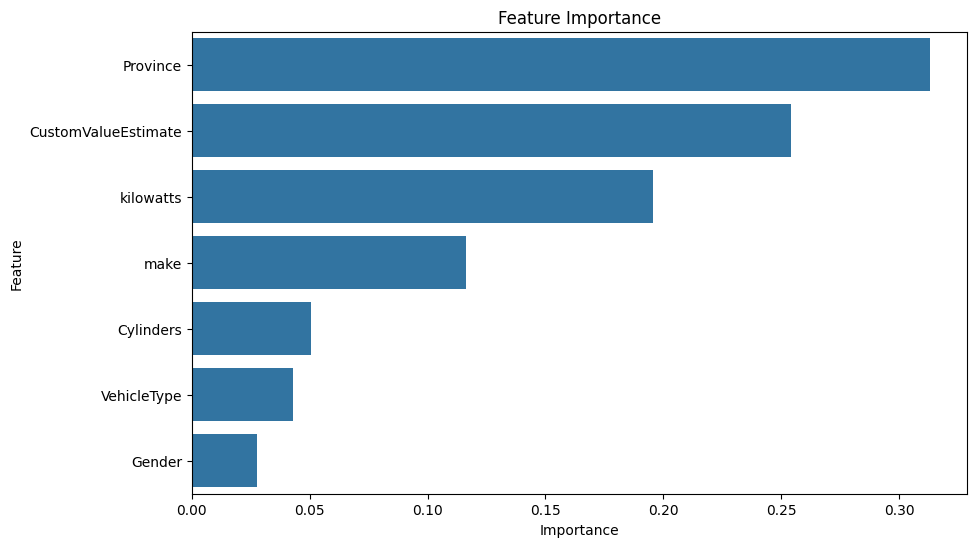

In [22]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": clf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.show()

In [23]:
(
    reg_model,
    X_test_r,
    y_test_r,
    pred_r,
    mae
) = train_claim_regressor(
    X,
    y_reg
)

print("MAE:", mae)

MAE: 129.2587037652254


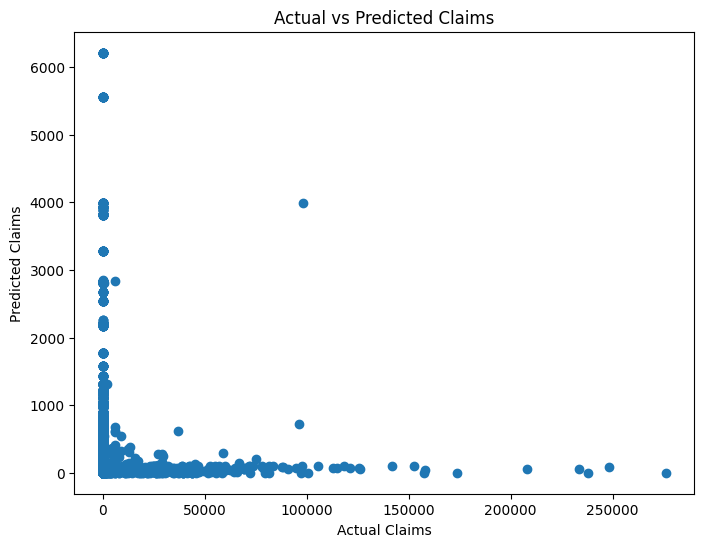

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_r,
    pred_r
)

plt.xlabel("Actual Claims")

plt.ylabel("Predicted Claims")

plt.title(
    "Actual vs Predicted Claims"
)

plt.show()

In [27]:
# 1. High-Level Metrics
# High-Level Insurance Portfolio Metrics

total_premiums = df['TotalPremium'].sum()

total_claims = df['TotalClaims'].sum()


# Create claim indicator
df['Claimed'] = df['TotalClaims'] > 0


# Claim frequency
overall_claim_rate = (
    df['Claimed'].mean()
) * 100


# Loss ratio
overall_loss_ratio = (
    total_claims / total_premiums
) * 100


# Average claim cost
average_claim_cost = (
    df[df['Claimed'] == True]
    ['TotalClaims']
    .mean()
)


# Create metrics table
metrics_df = pd.DataFrame({

    'Metric': [

        'Total Premiums Collected',

        'Total Claims Paid',

        'Overall Loss Ratio (%)',

        'Claim Frequency (%)',

        'Average Cost per Claim'
    ],

    'Value': [

        f"R {total_premiums:,.2f}",

        f"R {total_claims:,.2f}",

        f"{overall_loss_ratio:.2f}%",

        f"{overall_claim_rate:.2f}%",

        f"R {average_claim_cost:,.2f}"
    ]
})


print(
    "=== Portfolio Summary ==="
)

metrics_df

=== Portfolio Summary ===


,Metric,Value
0,Total Premiums Collected,"R 61,911,562.70"
1,Total Claims Paid,"R 64,867,546.17"
2,Overall Loss Ratio (%),104.77%
3,Claim Frequency (%),0.28%
4,Average Cost per Claim,"R 23,273.39"


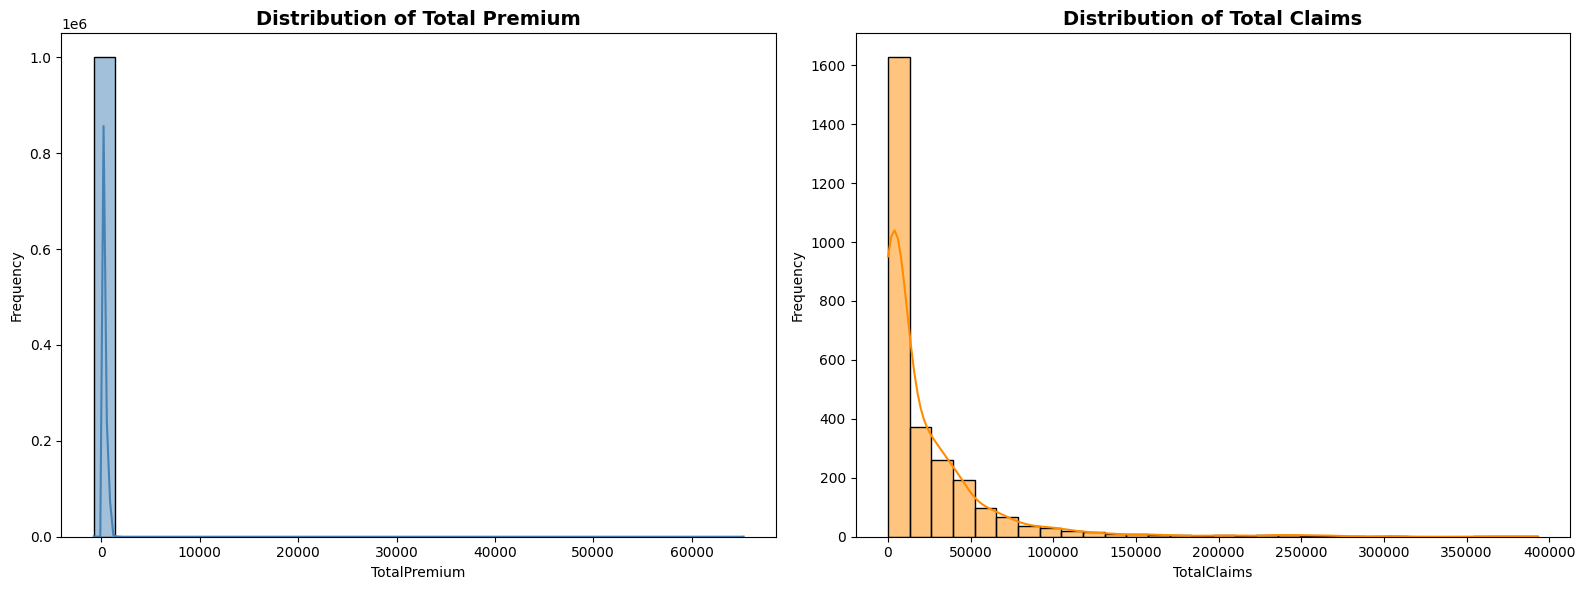

In [29]:
# Visualize Premium and Claims Distributions

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


# Distribution of TotalPremium
sns.histplot(
    df['TotalPremium'],
    kde=True,
    color='steelblue',
    ax=axes[0],
    bins=30
)

axes[0].set_title(
    'Distribution of Total Premium',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel(
    'TotalPremium'
)

axes[0].set_ylabel(
    'Frequency'
)


# Distribution of TotalClaims
# Excluding zero claims
sns.histplot(

    df[df['TotalClaims'] > 0]
    ['TotalClaims'],

    kde=True,

    color='darkorange',

    ax=axes[1],

    bins=30
)

axes[1].set_title(
    'Distribution of Total Claims',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel(
    'TotalClaims'
)

axes[1].set_ylabel(
    'Frequency'
)


plt.tight_layout()

plt.show()

C:\Users\edenteklehaimanot\AppData\Local\Temp\ipykernel_16512\3810025907.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\edenteklehaimanot\AppData\Local\Temp\ipykernel_16512\3810025907.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


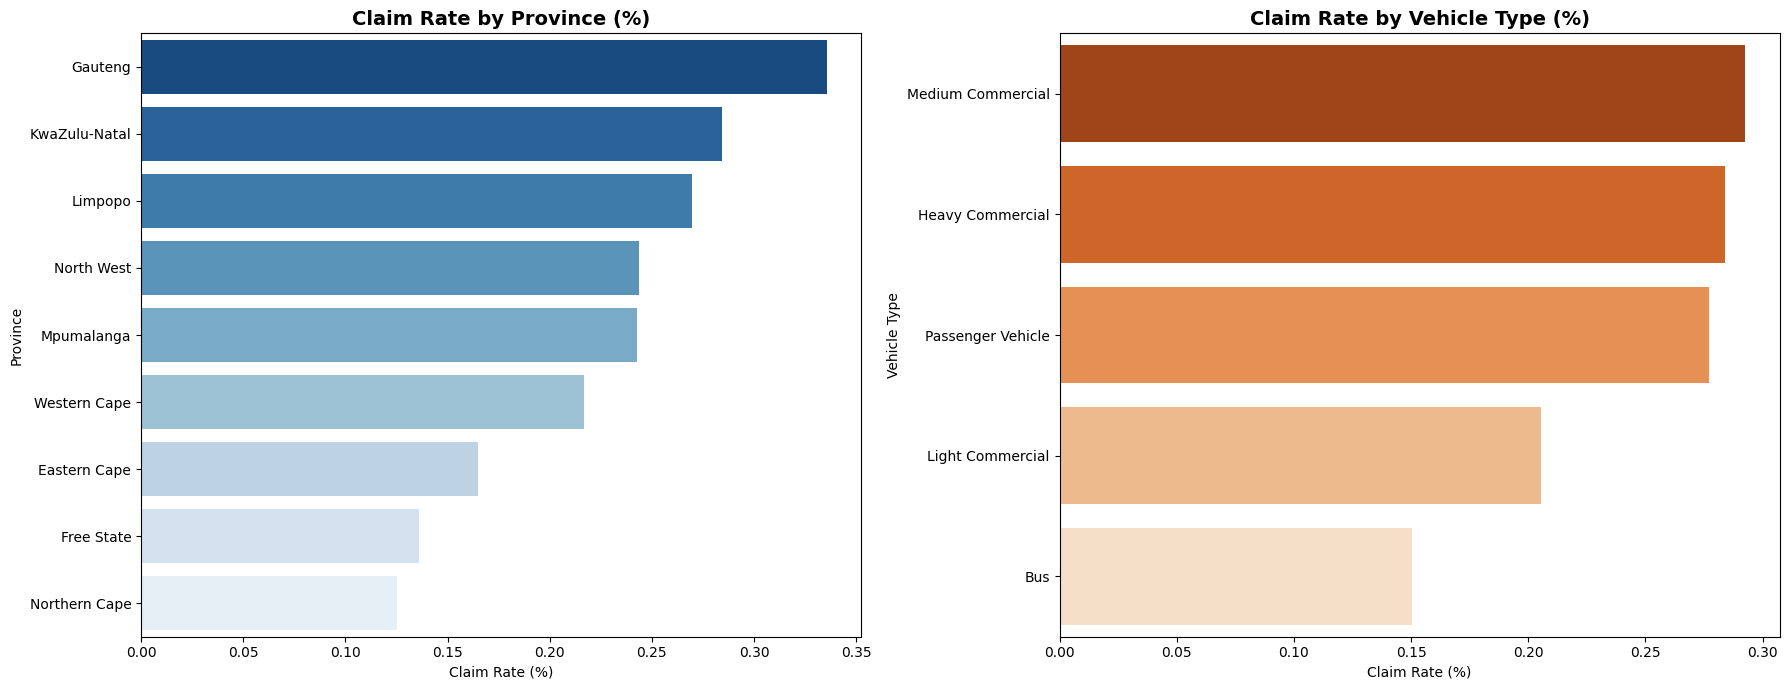

In [30]:
# Geographic and Vehicle Type Analysis

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)


# ==================================================
# Claim Rate by Province
# ==================================================

prov_claims = (
    df.groupby('Province')['Claimed']
    .mean()
    .reset_index()
)

# Convert to percentage
prov_claims['Claimed'] *= 100

# Sort descending
prov_claims = prov_claims.sort_values(
    by='Claimed',
    ascending=False
)


sns.barplot(

    data=prov_claims,

    x='Claimed',

    y='Province',

    palette='Blues_r',

    ax=axes[0]
)

axes[0].set_title(
    'Claim Rate by Province (%)',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Claim Rate (%)'
)

axes[0].set_ylabel(
    'Province'
)


# ==================================================
# Claim Rate by Vehicle Type
# ==================================================

veh_claims = (
    df.groupby('VehicleType')['Claimed']
    .mean()
    .reset_index()
)

# Convert to percentage
veh_claims['Claimed'] *= 100

# Sort descending
veh_claims = veh_claims.sort_values(
    by='Claimed',
    ascending=False
)


sns.barplot(

    data=veh_claims,

    x='Claimed',

    y='VehicleType',

    palette='Oranges_r',

    ax=axes[1]
)

axes[1].set_title(
    'Claim Rate by Vehicle Type (%)',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Claim Rate (%)'
)

axes[1].set_ylabel(
    'Vehicle Type'
)


plt.tight_layout()

plt.show()

In [ ]:
# 1. Correlation Matrix of Numerical Drivers
numerical_cols = ['Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'ClaimAmount']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Customer & Claims Metrics', fontsize=14, fontweight='bold', color=PALETTE['primary'])
plt.show()